## Data Exploration

In [1]:
# import library
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set() # Revert to matplotlib defaults
plt.rcParams['figure.figsize'] = (16, 12)

In [2]:
# load dataset
cleaned_df = pd.read_csv(r'C:\Users\Dell\Documents\my_linux\repos_\large-scale-solar-energy-generation\project_name\data\processed\cleaned_solar_data.csv')
cleaned_df.head()

,Date,Temperature,CloudOpacity,DHI,DNI,Radiation,Precipitation,Humidity,Pressure,WindDirection,WindSpeed,Month
0,2007-01-01,27.607692,0.969231,264.384615,130.307692,363.076923,24.838462,24.923077,996.446154,43.538462,2.384615,1
1,2007-01-02,27.753846,0.000000,264.153846,131.923077,363.076923,22.800000,24.384615,996.369231,84.615385,2.323077,1
2,2007-01-03,27.330769,0.000000,238.923077,228.615385,404.769231,21.838462,27.461538,995.376923,85.230769,1.592308,1
3,2007-01-04,27.946154,0.107692,242.769231,229.461538,406.384615,22.338462,37.769231,994.684615,73.923077,1.715385,1
4,2007-01-05,28.692308,0.000000,211.692308,311.692308,435.461538,21.953846,28.769231,994.038462,77.538462,2.161538,1


In [3]:
# Descriptive statistics summary
cleaned_df.describe()

,Temperature,CloudOpacity,DHI,DNI,Radiation,Precipitation,Humidity,Pressure,WindDirection,WindSpeed,Month
count,5565.000000,5565.000000,5565.000000,5565.000000,5565.000000,5565.000000,5565.000000,5565.000000,5565.000000,5565.000000,5565.000000
mean,27.236224,27.160534,262.766268,135.668135,362.175258,47.861716,75.556059,994.781170,202.770715,1.916751,6.452111
std,2.321850,17.865852,46.465022,115.150239,81.082722,9.648719,16.620785,1.967349,47.426305,0.679336,3.469920
min,21.746154,0.000000,20.916667,0.000000,20.916667,12.208333,11.923077,988.430769,18.846154,0.400000,1.000000
25%,25.338462,12.930769,237.769231,36.384615,315.769231,43.392308,69.153846,993.292308,190.538462,1.384615,3.000000
50%,27.061538,24.807692,269.923077,113.461538,376.230769,51.284615,79.769231,994.700000,211.153846,1.892308,6.000000
75%,28.784615,39.461538,295.769231,208.461538,420.538462,54.538462,87.500000,996.169231,229.230769,2.384615,9.000000
max,36.076923,89.341667,385.461538,585.076923,547.923077,67.700000,99.000000,1001.830769,319.923077,6.038462,12.000000


In [4]:
# check the missing values
cleaned_df.isnull().sum()

Date             0
Temperature      0
CloudOpacity     0
DHI              0
DNI              0
Radiation        0
Precipitation    0
Humidity         0
Pressure         0
WindDirection    0
WindSpeed        0
Month            0
dtype: int64

In [5]:
# summary of dataframe
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5565 entries, 0 to 5564
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           5565 non-null   object 
 1   Temperature    5565 non-null   float64
 2   CloudOpacity   5565 non-null   float64
 3   DHI            5565 non-null   float64
 4   DNI            5565 non-null   float64
 5   Radiation      5565 non-null   float64
 6   Precipitation  5565 non-null   float64
 7   Humidity       5565 non-null   float64
 8   Pressure       5565 non-null   float64
 9   WindDirection  5565 non-null   float64
 10  WindSpeed      5565 non-null   float64
 11  Month          5565 non-null   int64  
dtypes: float64(10), int64(1), object(1)
memory usage: 521.8+ KB


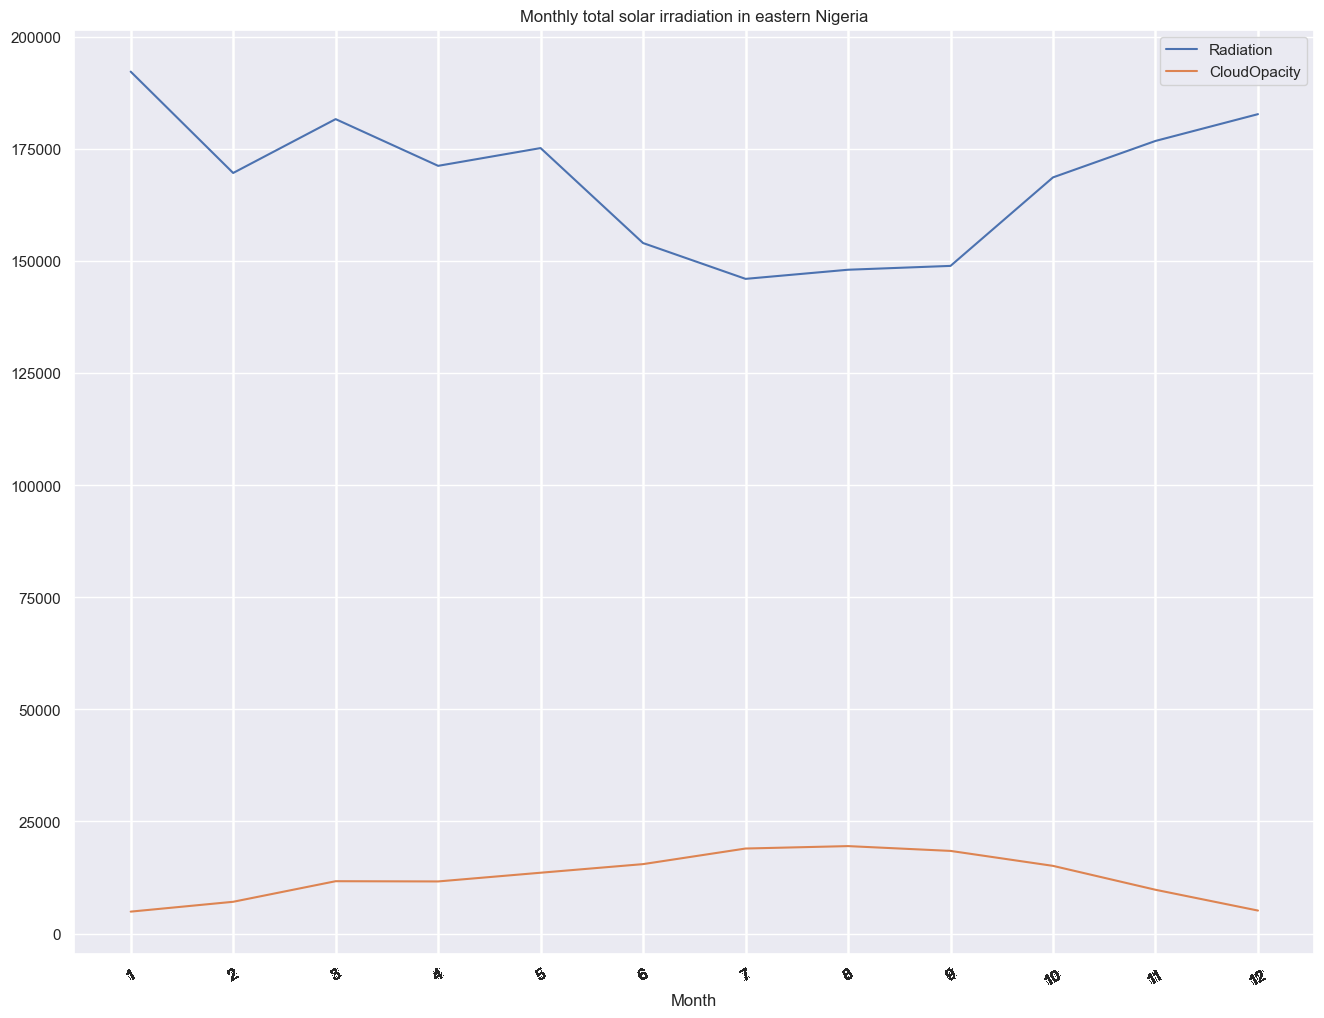

In [6]:
# A plot pf total irriadtion for each 
rad_vs_month= cleaned_df.loc[:, ['Radiation', 'CloudOpacity', 'Month']].groupby('Month').sum()
rad_vs_month.plot()
plt.xticks(cleaned_df['Month'], rotation = 30)
plt.title('Monthly total solar irradiation in eastern Nigeria')
plt.show()

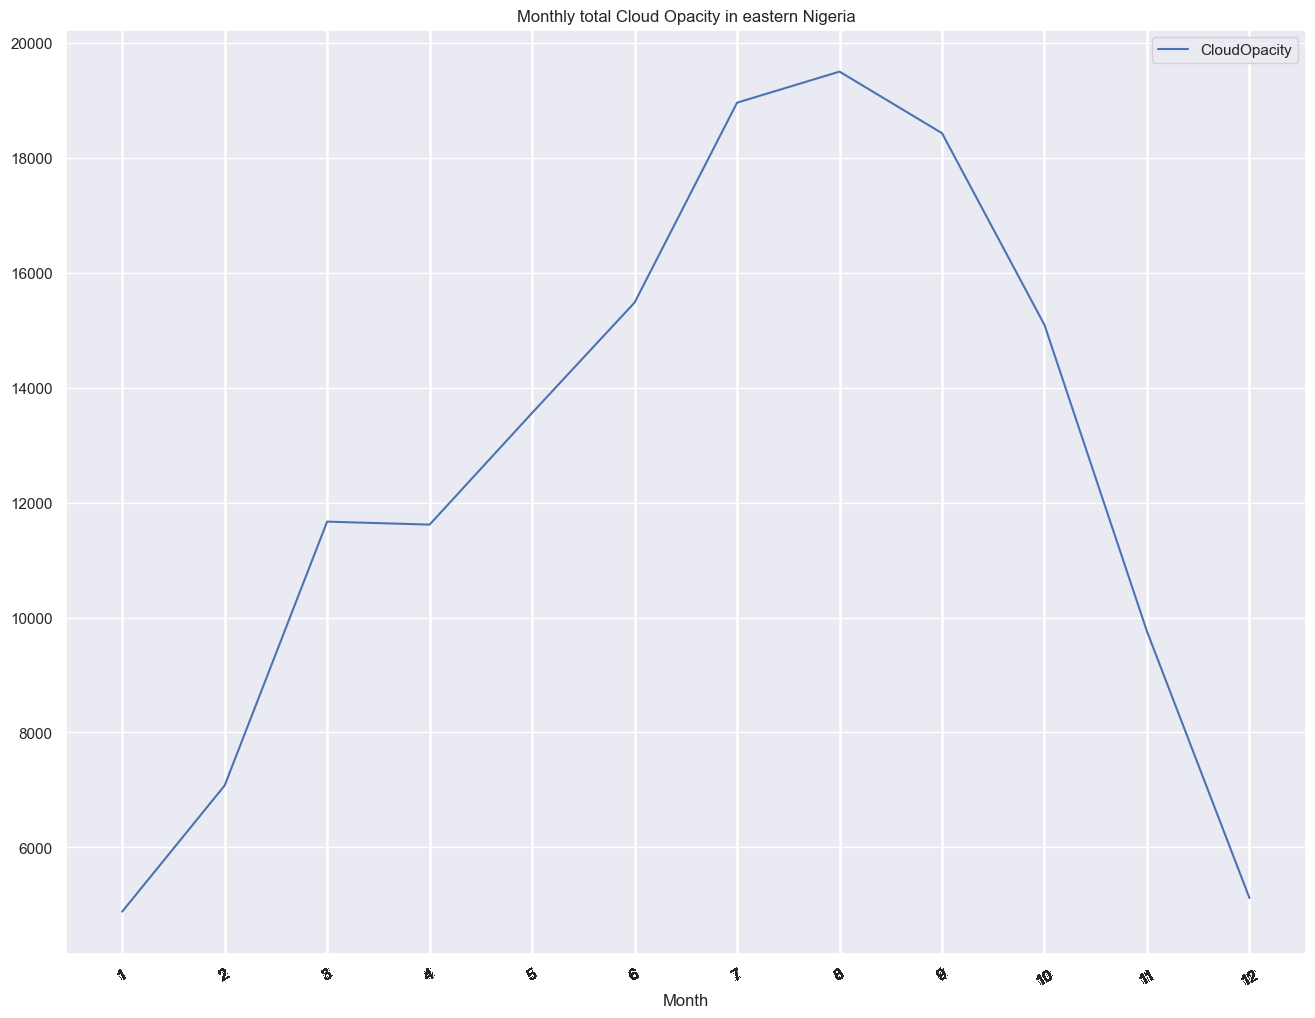

In [7]:
# A plot pf total irriadtion for each 
rad_vs_month = cleaned_df.loc[:, ['CloudOpacity', 'Month']].groupby('Month').sum()
rad_vs_month.plot()
plt.xticks(cleaned_df['Month'], rotation = 30)
plt.title('Monthly total Cloud Opacity in eastern Nigeria')
plt.show()

Locator attempting to generate 30603 ticks ([-278.2, ..., 5842.200000000001]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 30603 ticks ([-278.2, ..., 5842.200000000001]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 30603 ticks ([-278.2, ..., 5842.200000000001]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 30603 ticks ([-278.2, ..., 5842.200000000001]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 30603 ticks ([-278.2, ..., 5842.200000000001]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 30603 ticks ([-278.2, ..., 5842.200000000001]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 30603 ticks ([-278.2, ..., 5842.200000000001]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 30603 ticks ([-278.2, ..., 5842.200000000001]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 30603 ticks ([-278.2, ...

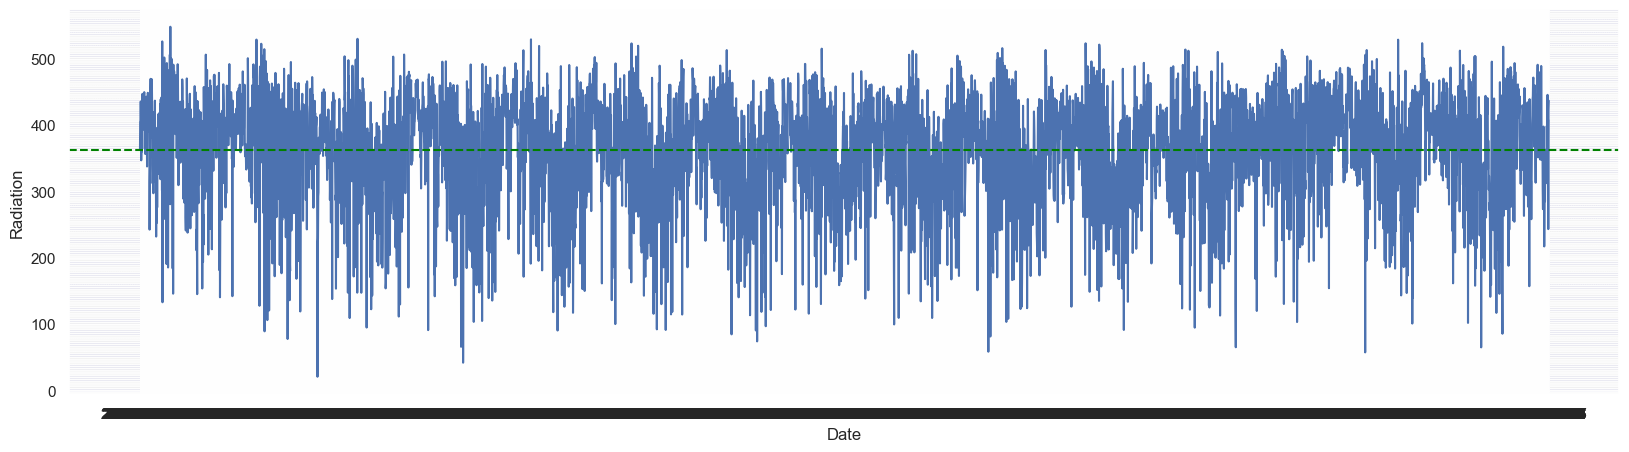

In [8]:
# Daily solar irradiation plot
f, ax = plt.subplots(figsize=(20, 5))
sns.lineplot(data = cleaned_df, x = "Date", y = "Radiation")

rad_avg= cleaned_df['Radiation'].mean()
ax.axhline(rad_avg, color='green', linestyle='--', label=f"Mean - {rad_avg:.2f}")

ax.set_axisbelow(True)
ax.minorticks_on()
ax.grid(which='major', linestyle='-', linewidth=0.5, color='white',)
ax.grid(which='minor', linestyle=':', linewidth=0.5, color='white', alpha=0.7)

plt.show()
ax.legend()

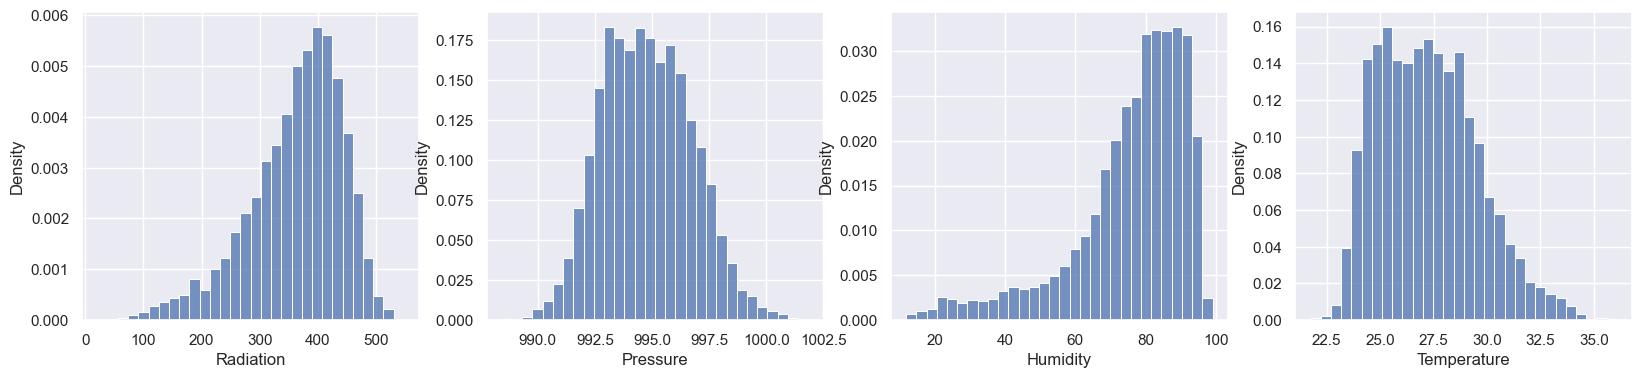

In [9]:
# Histogram distribution of weather features and solar irradiation
f, ax = plt.subplots(1, 4, figsize = (20,4))
sns.histplot(cleaned_df['Radiation'], stat = "density", bins = 30, ax = ax[0])
sns.histplot(cleaned_df['Pressure'], stat = "density", bins = 30, ax = ax[1])
sns.histplot(cleaned_df['Humidity'], stat = "density", bins = 30, ax = ax[2])
sns.histplot(cleaned_df['Temperature'], stat = "density", bins = 30, ax = ax[3])
plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_17460\2727910459.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = "Month", y = 'Radiation', data = cleaned_df, palette = "BuPu")


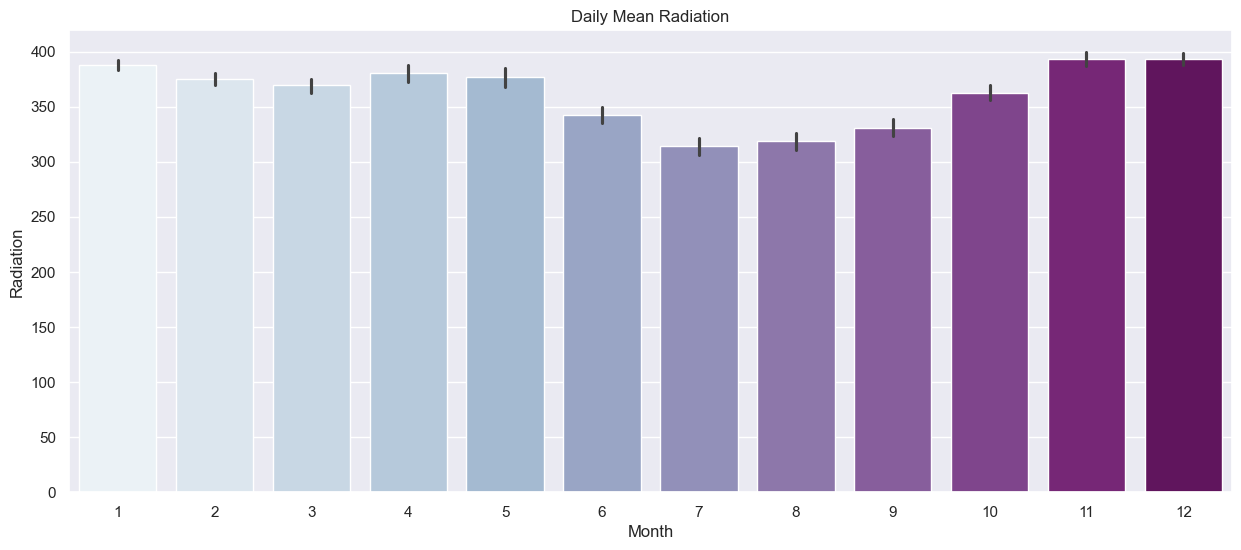

In [12]:
# Histogram plot of daily mean radiation
fig, ax = plt.subplots(figsize = (15, 6))
sns.barplot(x = "Month", y = 'Radiation', data = cleaned_df, palette = "BuPu")
ax.set_title('Daily Mean Radiation')
plt.show()

In [13]:
# feature correlation
corr = cleaned_df.corr(method = "pearson")

sns.heatmap(corr, mask = np.zeros_like(corr, dtype = np.bool), cmap = "coolwarm", square = True, annot = True, fmt = ".2f")
plt.show()

ValueError: could not convert string to float: '2007-01-01'